# 00B - Data Setup with Oversampling

Same as `00_Data_Setup.ipynb` but adds **Oversampling** for non-marked speed bumps.

Creates a NEW augmented dataset at `datasets/total-5-augmented/` (original stays untouched).

## Step 1 - Install dependencies

In [1]:
%pip install -q roboflow pyyaml matplotlib Pillow albumentations

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: c:\Users\MSI\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## Step 2 - Setup paths

In [2]:
import os

HOME = os.getcwd()
DATASET_DIR = os.path.join(HOME, 'datasets')

YOLO_PATH = os.path.join(DATASET_DIR, 'total-5')              # original data
COCO_PATH = os.path.join(DATASET_DIR, 'total-5-coco')         # COCO format
AUG_PATH  = os.path.join(DATASET_DIR, 'total-5-augmented')    # augmented copy

API_KEY = 'qPfRDo7AorEti39C5et4'
WORKSPACE = 'ensam-wyp9x'
PROJECT = 'total-jcwvt'
VERSION = 5

CLASS_NAMES = {
    0: 'marked-speed-bump',
    1: 'non-marked-speed-bump'
}

os.makedirs(DATASET_DIR, exist_ok=True)
print('Home:', HOME)
print('Original data:', YOLO_PATH)
print('Augmented data:', AUG_PATH)

Home: e:\Ventoy\bump detection project
Original data: e:\Ventoy\bump detection project\datasets\total-5
Augmented data: e:\Ventoy\bump detection project\datasets\total-5-augmented


## Step 3 - Download dataset (if not already downloaded)

In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)

# YOLOv8 format
yolo_train = os.path.join(YOLO_PATH, 'train', 'images')
if os.path.exists(yolo_train) and len(os.listdir(yolo_train)) > 0:
    print('YOLOv8 format already downloaded, skipping.')
else:
    print('Downloading YOLOv8 format...')
    version.download('yolov8', location=YOLO_PATH)
    print('Done!')

# COCO format
coco_train = os.path.join(COCO_PATH, 'train')
if os.path.exists(coco_train) and len(os.listdir(coco_train)) > 0:
    print('COCO format already downloaded, skipping.')
else:
    print('Downloading COCO format...')
    version.download('coco', location=COCO_PATH)
    print('Done!')

loading Roboflow workspace...
loading Roboflow project...
YOLOv8 format already downloaded, skipping.
COCO format already downloaded, skipping.


## Step 4 - Fix data.yaml class names

In [4]:
import yaml

yaml_path = os.path.join(YOLO_PATH, 'data.yaml')

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

print('BEFORE:', config['names'])

config['names'] = ['marked-speed-bump', 'non-marked-speed-bump']
config['train'] = os.path.join(YOLO_PATH, 'train', 'images')
config['val']   = os.path.join(YOLO_PATH, 'valid', 'images')
config['test']  = os.path.join(YOLO_PATH, 'test', 'images')

with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print('AFTER:', config['names'])
print('data.yaml fixed!')

BEFORE: ['marked-speed-bump', 'non-marked-speed-bump']
AFTER: ['marked-speed-bump', 'non-marked-speed-bump']
data.yaml fixed!


## Step 5 - Check annotations and count classes (same as original)

In [5]:
import matplotlib.pyplot as plt

counts = {}

for split in ['train', 'valid', 'test']:
    lbl_dir = os.path.join(YOLO_PATH, split, 'labels')
    counts[split] = {0: 0, 1: 0}

    for filename in os.listdir(lbl_dir):
        if not filename.endswith('.txt'):
            continue
        filepath = os.path.join(lbl_dir, filename)
        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    class_id = int(line.split()[0])
                    counts[split][class_id] = counts[split].get(class_id, 0) + 1

    print(f'{split.upper()}: marked={counts[split][0]}, non-marked={counts[split][1]}')

total_marked = counts['train'][0] + counts['valid'][0] + counts['test'][0]
total_non_marked = counts['train'][1] + counts['valid'][1] + counts['test'][1]
ratio = total_marked / max(total_non_marked, 1)
print(f'\nTotal: marked={total_marked}, non-marked={total_non_marked}, ratio={ratio:.1f}:1')

TRAIN: marked=666, non-marked=39
VALID: marked=198, non-marked=8
TEST: marked=77, non-marked=4

Total: marked=941, non-marked=51, ratio=18.5:1


## Step 6 - Copy original dataset to augmented folder

We copy everything first, then add augmented images on top.
This keeps the original dataset completely untouched.

In [6]:
import shutil

if os.path.exists(AUG_PATH):
    print('Augmented folder already exists. Deleting it to start fresh...')
    shutil.rmtree(AUG_PATH)

print('Copying original dataset to augmented folder...')
shutil.copytree(YOLO_PATH, AUG_PATH)
print(f'Copied to: {AUG_PATH}')

Copying original dataset to augmented folder...
Copied to: e:\Ventoy\bump detection project\datasets\total-5-augmented


## Step 7 - Find all non-marked speed bump images

We scan the training labels to find which images contain class 1 (non-marked).

In [7]:
# Find images that have non-marked speed bumps (class 1)
non_marked_files = []

train_lbl_dir = os.path.join(YOLO_PATH, 'train', 'labels')

for filename in os.listdir(train_lbl_dir):
    if not filename.endswith('.txt'):
        continue

    filepath = os.path.join(train_lbl_dir, filename)
    with open(filepath, 'r') as f:
        content = f.read()

    # Check if any line starts with '1 ' (class 1)
    for line in content.strip().split('\n'):
        if line.startswith('1 '):
            name = filename.rsplit('.', 1)[0]  # remove .txt
            non_marked_files.append(name)
            break

print(f'Found {len(non_marked_files)} training images with non-marked speed bumps')

Found 38 training images with non-marked speed bumps


## Step 8 - Oversample with Albumentations

For each non-marked image, we create **8 augmented copies** using:
1. **Brightness/Contrast change** - simulates different times of day
2. **Horizontal flip** - mirror image, like looking from the other lane
3. **Blur** - simulates camera shake or dirty lens
4. **Hue/Saturation shift** - changes colors slightly

Albumentations automatically adjusts the bounding boxes too!

In [8]:
import albumentations as A
from PIL import Image
import numpy as np

# How many augmented copies per image
COPIES_PER_IMAGE = 8

# Define the augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.5),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.GaussNoise(p=0.2),
], bbox_params=A.BboxParams(
    format='yolo',           # our labels are in YOLO format
    label_fields=['class_ids'],
    min_visibility=0.3       # keep boxes that are at least 30% visible
))

# Paths for the augmented dataset
aug_img_dir = os.path.join(AUG_PATH, 'train', 'images')
aug_lbl_dir = os.path.join(AUG_PATH, 'train', 'labels')
orig_img_dir = os.path.join(YOLO_PATH, 'train', 'images')
orig_lbl_dir = os.path.join(YOLO_PATH, 'train', 'labels')

total_created = 0

for name in non_marked_files:

    # Find the image file (could be .jpg or .png)
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        candidate = os.path.join(orig_img_dir, name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            img_ext = ext
            break

    if img_path is None:
        print(f'  WARNING: No image found for {name}, skipping')
        continue

    # Read image
    img = np.array(Image.open(img_path))

    # Read labels
    lbl_path = os.path.join(orig_lbl_dir, name + '.txt')
    bboxes = []
    class_ids = []
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_ids.append(int(parts[0]))
                bboxes.append([float(parts[1]), float(parts[2]),
                               float(parts[3]), float(parts[4])])

    # Generate augmented copies
    for i in range(COPIES_PER_IMAGE):
        result = augment(image=img, bboxes=bboxes, class_ids=class_ids)

        # Skip if all bounding boxes were lost
        if len(result['bboxes']) == 0:
            continue

        # Save augmented image
        new_name = f'{name}_aug{i}'
        new_img_path = os.path.join(aug_img_dir, new_name + img_ext)
        Image.fromarray(result['image']).save(new_img_path)

        # Save augmented labels
        new_lbl_path = os.path.join(aug_lbl_dir, new_name + '.txt')
        with open(new_lbl_path, 'w') as f:
            for cls_id, bbox in zip(result['class_ids'], result['bboxes']):
                f.write(f'{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n')

        total_created += 1

print(f'\nCreated {total_created} augmented images!')
print(f'Saved to: {aug_img_dir}')


Created 304 augmented images!
Saved to: e:\Ventoy\bump detection project\datasets\total-5-augmented\train\images


## Step 9 - Update augmented data.yaml

In [9]:
import yaml

aug_yaml_path = os.path.join(AUG_PATH, 'data.yaml')

with open(aug_yaml_path, 'r') as f:
    aug_config = yaml.safe_load(f)

aug_config['names'] = ['marked-speed-bump', 'non-marked-speed-bump']
aug_config['train'] = os.path.join(AUG_PATH, 'train', 'images')
aug_config['val']   = os.path.join(AUG_PATH, 'valid', 'images')
aug_config['test']  = os.path.join(AUG_PATH, 'test', 'images')

with open(aug_yaml_path, 'w') as f:
    yaml.dump(aug_config, f, default_flow_style=False)

print('Augmented data.yaml updated!')

Augmented data.yaml updated!


## Step 10 - Verify: count classes AFTER augmentation

In [12]:
# Count in augmented train set
aug_lbl_dir = os.path.join(AUG_PATH, 'train', 'labels')
aug_counts = {0: 0, 1: 0}

for filename in os.listdir(aug_lbl_dir):
    if not filename.endswith('.txt'):
        continue
    filepath = os.path.join(aug_lbl_dir, filename)
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                # التعديل هنا: استخدام float قبل int
                class_id = int(float(line.split()[0]))
                aug_counts[class_id] = aug_counts.get(class_id, 0) + 1

print('BEFORE augmentation (train only):')
print(f'  marked:     {counts["train"][0]}')
print(f'  non-marked: {counts["train"][1]}')

print(f'\nAFTER augmentation (train only):')
print(f'  marked:     {aug_counts[0]}')
print(f'  non-marked: {aug_counts[1]}')

new_ratio = aug_counts[0] / max(aug_counts[1], 1)
print(f'\nNew ratio: {new_ratio:.1f}:1')

if new_ratio < 5:
    print('Balance improved significantly!')
else:
    print('Still imbalanced. Consider increasing COPIES_PER_IMAGE.')


BEFORE augmentation (train only):
  marked:     666
  non-marked: 39

AFTER augmentation (train only):
  marked:     674
  non-marked: 351

New ratio: 1.9:1
Balance improved significantly!


## Step 11 - Show some augmented samples

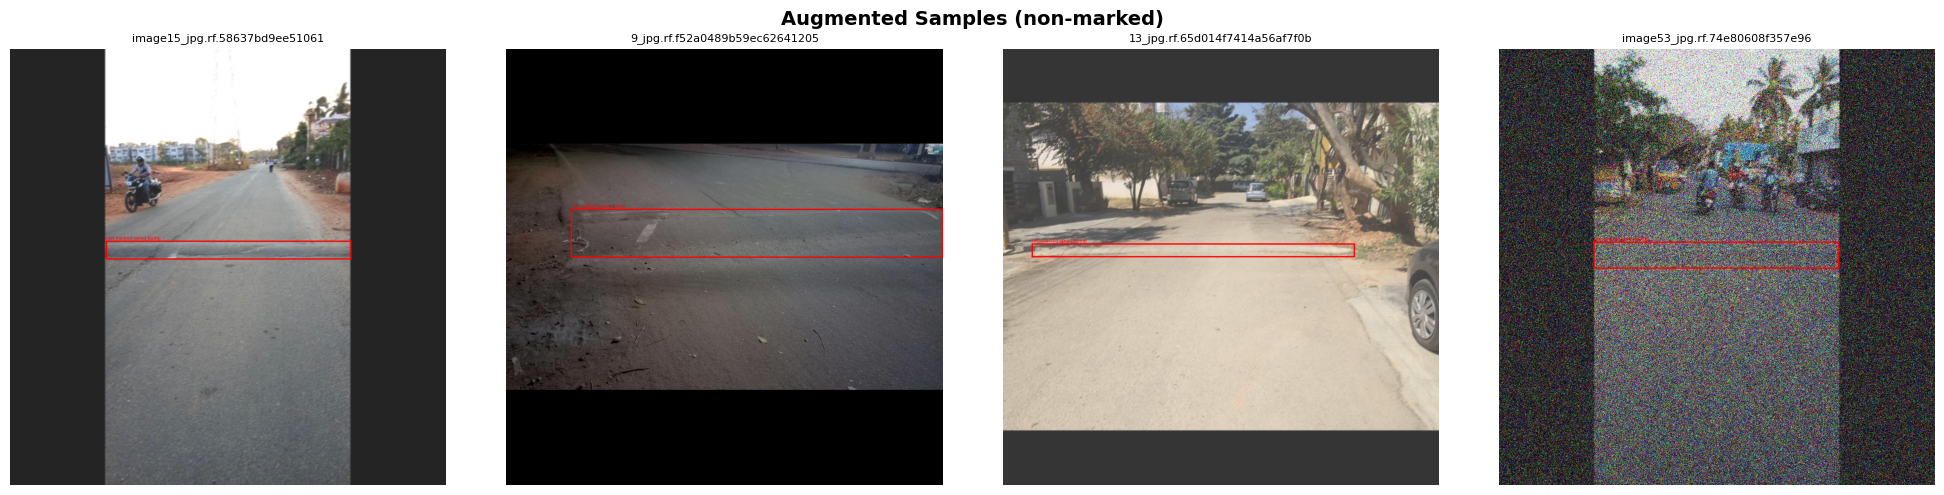

In [16]:
from PIL import Image, ImageDraw
import random
import matplotlib.pyplot as plt

aug_img_dir = os.path.join(AUG_PATH, 'train', 'images')
aug_lbl_dir = os.path.join(AUG_PATH, 'train', 'labels')

# Find augmented images only (they have '_aug' in the name)
aug_images = [f for f in os.listdir(aug_img_dir) if '_aug' in f]
chosen = random.sample(aug_images, min(4, len(aug_images)))

fig, axes = plt.subplots(1, len(chosen), figsize=(5 * len(chosen), 5))
if len(chosen) == 1:
    axes = [axes]

for ax, img_name in zip(axes, chosen):
    img = Image.open(os.path.join(aug_img_dir, img_name))
    draw = ImageDraw.Draw(img)
    w, h = img.size

    label_name = img_name.rsplit('.', 1)[0] + '.txt'
    label_path = os.path.join(aug_lbl_dir, label_name)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                cx = float(parts[1]) * w
                cy = float(parts[2]) * h
                bw = float(parts[3]) * w
                bh = float(parts[4]) * h

                x1 = cx - bw / 2
                y1 = cy - bh / 2
                x2 = cx + bw / 2
                y2 = cy + bh / 2

                color = 'lime' if cls_id == 0 else 'red'
                draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
                draw.text((x1, y1 - 12), CLASS_NAMES.get(cls_id, '?'), fill=color)

    ax.imshow(img)
    ax.set_title(img_name[:30], fontsize=8)
    ax.axis('off')

plt.suptitle('Augmented Samples (non-marked)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Done!

You now have **two datasets**:

| Dataset | Path | Purpose |
|---------|------|---------|
| Original (imbalanced) | `datasets/total-5/` | Baseline experiment |
| Augmented (balanced) | `datasets/total-5-augmented/` | Fair experiment |
| COCO format | `datasets/total-5-coco/` | RT-DETR experiment |

In the YOLOv8 experiment, train **twice**:
1. Once with `datasets/total-5/data.yaml` (baseline)
2. Once with `datasets/total-5-augmented/data.yaml` (augmented)

Then compare the per-class mAP to see if oversampling helped.